# Fase 2 – Preparación, exploración y validación de datos

## Proyecto: Generación eléctrica real de centrales CMPC

Este notebook documenta de forma reproducible la preparación del conjunto de datos público descargado desde el **Coordinador Eléctrico Nacional (CEN)**.

**Fuente oficial:** Coordinador Eléctrico Nacional – Generación Real  
https://www.coordinador.cl/operacion/graficos/operacion-real/generacion-real-/

**Período analizado:** enero a agosto de 2026.

**Centrales incluidas en el alcance:**
- TER CMPC LAJA
- TER CMPC PACIFICO
- TER CMPC SANTA FE

La fuente original presenta una fila por central y fecha, junto con 24 columnas horarias (`Hora 1` a `Hora 24`). En esta fase se transforma el archivo a **formato largo**, de modo que cada fila represente una observación de generación para una central, una fecha y una hora.

> **Criterio metodológico sobre valores cero:** los registros de generación iguales a 0 MWh se conservan como observaciones válidas. En este proyecto no se atribuye automáticamente una causa operacional a esos valores, salvo que exista documentación oficial que permita hacerlo.


## 1. Configuración del entorno

Se importan las bibliotecas utilizadas en la preparación, validación y visualización de los datos.

El proyecto utiliza rutas relativas para evitar depender de una ubicación específica del computador de una integrante del equipo.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Versiones del entorno")
print("Python: se utiliza el intérprete configurado en el entorno virtual del proyecto")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Versiones del entorno
Python: se utiliza el intérprete configurado en el entorno virtual del proyecto
pandas: 3.0.5
numpy: 2.5.3


## 2. Identificación de la carpeta raíz del proyecto

El notebook puede ejecutarse tanto si Jupyter se inicia desde la raíz del repositorio como si se inicia desde la carpeta `F2`.

La función siguiente busca hacia arriba una carpeta que contenga simultáneamente `data` y `F2`.


In [2]:
def encontrar_raiz_proyecto(ruta_inicial: Path) -> Path:
    """Busca la raíz del proyecto a partir de una ruta inicial."""
    ruta = ruta_inicial.resolve()

    for candidata in [ruta, *ruta.parents]:
        if (candidata / "data").exists() and (candidata / "F2").exists():
            return candidata

    raise FileNotFoundError(
        "No se pudo identificar la raíz del proyecto. "
        "Verifique que existan las carpetas 'data' y 'F2'."
    )


ruta_proyecto = encontrar_raiz_proyecto(Path.cwd())
ruta_raw = ruta_proyecto / "data" / "raw" / "generacion_real_cen_ene_ago_2026.csv"
ruta_processed = (
    ruta_proyecto
    / "data"
    / "processed"
    / "dataset_cen_centrales_cmpc_ene_ago_2026.csv"
)

print("Raíz del proyecto:", ruta_proyecto)
print("Archivo RAW:", ruta_raw)
print("Archivo procesado:", ruta_processed)


Raíz del proyecto: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto
Archivo RAW: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\raw\generacion_real_cen_ene_ago_2026.csv
Archivo procesado: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\processed\dataset_cen_centrales_cmpc_ene_ago_2026.csv


## 3. Carga de la descarga original del CEN

El archivo del CEN utiliza:

- separador `;`;
- coma como separador decimal;
- codificación compatible con UTF-8;
- 24 columnas de generación horaria.

La descarga original se mantiene en `data/raw` y no se versiona en Git, porque es un archivo grande y su fuente pública está documentada.


In [3]:
if not ruta_raw.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo RAW esperado:\n{ruta_raw}\n"
        "Descargue la fuente pública del CEN y guárdela con el nombre "
        "'generacion_real_cen_ene_ago_2026.csv' dentro de data/raw."
    )

df_raw = pd.read_csv(
    ruta_raw,
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
    low_memory=False
)

print("Carga completada.")
print("Filas:", f"{df_raw.shape[0]:,}".replace(",", "."))
print("Columnas:", df_raw.shape[1])


Carga completada.
Filas: 359.891
Columnas: 33


## 4. Validación de la estructura de la fuente

Antes de realizar transformaciones se verifica que estén presentes las variables esperadas.

Esta validación permite detectar cambios de estructura en la fuente antes de continuar con el procesamiento.


In [4]:
columnas_base = [
    "Año",
    "Mes",
    "Llave",
    "Central",
    "Coordinado",
    "Grupo reporte",
    "Tipo",
    "Subtipo",
    "Fecha",
]

columnas_horarias = [f"Hora {i}" for i in range(1, 25)]
columnas_esperadas = columnas_base + columnas_horarias

faltantes_estructura = [
    columna for columna in columnas_esperadas
    if columna not in df_raw.columns
]

assert not faltantes_estructura, (
    "Faltan columnas esperadas en la fuente: "
    + ", ".join(faltantes_estructura)
)

print("Estructura validada correctamente.")
print("Columnas horarias detectadas:", len(columnas_horarias))


Estructura validada correctamente.
Columnas horarias detectadas: 24


In [5]:
print("PRIMERAS FILAS DE LA FUENTE")
display(df_raw.head())

print("\nTIPOS DE DATOS")
display(df_raw.dtypes.to_frame("tipo"))

print("\nRESUMEN GENERAL")
print("Dimensiones:", df_raw.shape)
print("Duplicados exactos:", int(df_raw.duplicated().sum()))
print("Valores nulos totales:", int(df_raw.isna().sum().sum()))


PRIMERAS FILAS DE LA FUENTE


,Año,Mes,Llave,Central,Coordinado,Grupo reporte,Tipo,Subtipo,Fecha,Hora 1,...,Hora 15,Hora 16,Hora 17,Hora 18,Hora 19,Hora 20,Hora 21,Hora 22,Hora 23,Hora 24
0,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-01,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-02,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-03,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



TIPOS DE DATOS


,tipo
Año,int64
Mes,str
Llave,str
Central,str
Coordinado,str
Grupo reporte,str
Tipo,str
Subtipo,str
Fecha,str
Hora 1,float64



RESUMEN GENERAL
Dimensiones: (359891, 33)
Duplicados exactos: 0
Valores nulos totales: 0


## 5. Preparación de la variable Fecha

La variable `Fecha` se convierte a tipo temporal antes de aplicar filtros y derivar nuevas variables.


In [6]:
df_raw["Fecha"] = pd.to_datetime(
    df_raw["Fecha"],
    errors="raise"
)

print("Fecha mínima:", df_raw["Fecha"].min().date())
print("Fecha máxima:", df_raw["Fecha"].max().date())


Fecha mínima: 2026-01-01
Fecha máxima: 2026-08-31


## 6. Definición del alcance analítico

Se seleccionan únicamente tres centrales termoeléctricas de biomasa asociadas al alcance definido para el proyecto.

La selección se realiza mediante nombres exactos para evitar incorporar instalaciones no contempladas.


In [7]:
centrales_objetivo = [
    "TER CMPC LAJA",
    "TER CMPC PACIFICO",
    "TER CMPC SANTA FE",
]

df_seleccion = df_raw[
    df_raw["Central"].isin(centrales_objetivo)
].copy()

print("Filas seleccionadas en formato original:", df_seleccion.shape[0])
display(
    df_seleccion["Central"]
    .value_counts()
    .rename("registros_diarios")
    .to_frame()
)


Filas seleccionadas en formato original: 729


,registros_diarios
Central,
TER CMPC LAJA,243
TER CMPC PACIFICO,243
TER CMPC SANTA FE,243


### Validación de la selección

Para el período comprendido entre el 1 de enero y el 31 de agosto de 2026 existen 243 fechas. Cada una de las tres centrales debe tener una observación diaria en la estructura original de la descarga.


In [8]:
fecha_inicio = pd.Timestamp("2026-01-01")
fecha_fin = pd.Timestamp("2026-08-31")
fechas_esperadas = pd.date_range(fecha_inicio, fecha_fin, freq="D")

conteo_por_central = (
    df_seleccion.groupby("Central")["Fecha"]
    .nunique()
    .reindex(centrales_objetivo)
)

assert set(df_seleccion["Central"].unique()) == set(centrales_objetivo),     "La selección no contiene exactamente las tres centrales objetivo."

assert (conteo_por_central == len(fechas_esperadas)).all(),     "Alguna central no contiene todas las fechas esperadas del período."

assert df_seleccion.shape[0] == len(fechas_esperadas) * len(centrales_objetivo),     "La cantidad de registros diarios seleccionados no coincide con lo esperado."

print("Selección validada.")
print("Fechas esperadas por central:", len(fechas_esperadas))
print("Registros diarios totales:", df_seleccion.shape[0])


Selección validada.
Fechas esperadas por central: 243
Registros diarios totales: 729


## 7. Transformación de formato ancho a formato largo

En la descarga original, las mediciones horarias se encuentran distribuidas en 24 columnas.

Se utiliza `melt()` para transformar esas columnas en filas. Así se establece una única unidad de observación:

> **Una fila = generación eléctrica de una central, en una fecha y una hora determinada, expresada en MWh.**

La numeración horaria se conserva exactamente como aparece en la fuente (`1` a `24`) y no se asigna una interpretación adicional del reloj que no esté documentada.


In [9]:
id_vars = [
    "Año",
    "Mes",
    "Llave",
    "Central",
    "Coordinado",
    "Grupo reporte",
    "Tipo",
    "Subtipo",
    "Fecha",
]

df_long = df_seleccion.melt(
    id_vars=id_vars,
    value_vars=columnas_horarias,
    var_name="Hora_Origen",
    value_name="Generacion_MWh"
)

df_long["Hora"] = (
    df_long["Hora_Origen"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

print("Dimensiones después de transformar a formato largo:", df_long.shape)
display(df_long.head())


Dimensiones después de transformar a formato largo: (17496, 12)


,Año,Mes,Llave,Central,Coordinado,Grupo reporte,Tipo,Subtipo,Fecha,Hora_Origen,Generacion_MWh,Hora
0,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Hora 1,1.1,1
1,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-02,Hora 1,9.7,1
2,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-03,Hora 1,17.4,1
3,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-04,Hora 1,16.5,1
4,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-05,Hora 1,14.5,1


## 8. Construcción de variables derivadas

Se incorporan dos variables que facilitan el análisis y la trazabilidad:

- `Dia_Semana`: derivada reproduciblemente desde `Fecha`.
- `ID_Observacion`: identificador único construido a partir de central, fecha y hora.

Además, `Grupo reporte` se renombra como `Grupo_Reporte` para mantener una convención uniforme.


In [10]:
dias_espanol = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

df_long["Dia_Semana"] = (
    df_long["Fecha"]
    .dt.dayofweek
    .map(dias_espanol)
)

df_long["ID_Observacion"] = (
    df_long["Central"].str.replace(" ", "_", regex=False)
    + "|"
    + df_long["Fecha"].dt.strftime("%Y-%m-%d")
    + "|H"
    + df_long["Hora"].astype(str).str.zfill(2)
)

df_long = df_long.rename(
    columns={"Grupo reporte": "Grupo_Reporte"}
)


## 9. Construcción del dataset analítico

Se seleccionan y ordenan 13 variables finales.

El conjunto resultante combina variables temporales, numéricas y categóricas, además de un identificador textual de alta cardinalidad.


In [11]:
columnas_finales = [
    "ID_Observacion",
    "Año",
    "Mes",
    "Llave",
    "Central",
    "Coordinado",
    "Grupo_Reporte",
    "Tipo",
    "Subtipo",
    "Fecha",
    "Dia_Semana",
    "Hora",
    "Generacion_MWh",
]

df = (
    df_long[columnas_finales]
    .sort_values(["Central", "Fecha", "Hora"])
    .reset_index(drop=True)
)

print("DIMENSIONES DEL DATASET ANALÍTICO")
print("Filas:", f"{df.shape[0]:,}".replace(",", "."))
print("Columnas:", df.shape[1])

display(df.head())


DIMENSIONES DEL DATASET ANALÍTICO
Filas: 17.496
Columnas: 13


,ID_Observacion,Año,Mes,Llave,Central,Coordinado,Grupo_Reporte,Tipo,Subtipo,Fecha,Dia_Semana,Hora,Generacion_MWh
0,TER_CMPC_LAJA|2026-01-01|H01,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,1,1.1
1,TER_CMPC_LAJA|2026-01-01|H02,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,2,11.4
2,TER_CMPC_LAJA|2026-01-01|H03,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,3,10.3
3,TER_CMPC_LAJA|2026-01-01|H04,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,4,6.9
4,TER_CMPC_LAJA|2026-01-01|H05,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,5,8.4


## 10. Validación de calidad de datos

Se comprueban los criterios técnicos principales del conjunto de datos:

- mínimo 2.000 observaciones;
- mínimo 12 variables;
- presencia de variable temporal;
- presencia de variable numérica;
- presencia de variables categóricas;
- ausencia de duplicados exactos;
- identificador único;
- porcentaje de datos faltantes inferior al 60 % en todas las variables;
- presencia de las tres centrales objetivo;
- rango horario de 1 a 24.


In [12]:
porcentaje_nulos = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

duplicados_exactos = int(df.duplicated().sum())
duplicados_id = int(df["ID_Observacion"].duplicated().sum())

assert df.shape[0] >= 2000, "El dataset tiene menos de 2.000 filas."
assert df.shape[1] >= 12, "El dataset tiene menos de 12 columnas."
assert pd.api.types.is_datetime64_any_dtype(df["Fecha"]),     "Fecha no quedó como variable temporal."
assert pd.api.types.is_numeric_dtype(df["Generacion_MWh"]),     "Generacion_MWh no es numérica."
assert pd.api.types.is_string_dtype(df["Central"]), \
    "Central no está disponible como variable categórica/textual."
assert porcentaje_nulos.max() <= 60,     "Existe al menos una variable con más de 60 % de datos faltantes."
assert duplicados_exactos == 0, "Existen filas exactamente duplicadas."
assert duplicados_id == 0, "Existen ID_Observacion duplicados."
assert set(df["Central"].unique()) == set(centrales_objetivo),     "El dataset final no contiene exactamente las tres centrales objetivo."
assert df["Hora"].between(1, 24).all(),     "Se detectaron valores de Hora fuera del rango 1-24."
assert df.shape[0] == 17496,     "La cantidad final de observaciones no coincide con 3 centrales × 243 días × 24 horas."

print("Todas las validaciones principales fueron superadas.")


Todas las validaciones principales fueron superadas.


In [13]:
diagnostico = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Nulos": df.isna().sum(),
    "Nulos_%": (df.isna().mean() * 100).round(2),
    "Unicos": df.nunique(dropna=False),
})

display(diagnostico)


,Tipo,Nulos,Nulos_%,Unicos
ID_Observacion,str,0,0.0,17496
Año,int64,0,0.0,1
Mes,str,0,0.0,8
Llave,str,0,0.0,3
Central,str,0,0.0,3
Coordinado,str,0,0.0,1
Grupo_Reporte,str,0,0.0,3
Tipo,str,0,0.0,1
Subtipo,str,0,0.0,1
Fecha,datetime64[us],0,0.0,243


## 11. Revisión de valores de generación

Los valores iguales a cero se conservan. No se eliminan ni se imputan porque forman parte de los registros publicados por la fuente.

También se comprueba si existen valores negativos, sin asumir previamente que su existencia sea imposible por definición.


In [14]:
resumen_generacion = (
    df.groupby("Central")["Generacion_MWh"]
    .agg(
        Observaciones="count",
        Minimo="min",
        Promedio="mean",
        Mediana="median",
        Maximo="max",
    )
)

ceros_por_central = (
    df.assign(Es_Cero=df["Generacion_MWh"].eq(0))
    .groupby("Central")["Es_Cero"]
    .agg(Ceros="sum", Observaciones="count")
)

ceros_por_central["Porcentaje_Ceros"] = (
    ceros_por_central["Ceros"]
    / ceros_por_central["Observaciones"]
    * 100
).round(2)

valores_negativos = int(df["Generacion_MWh"].lt(0).sum())

print("RESUMEN DE GENERACIÓN")
display(resumen_generacion.round(3))

print("\nREGISTROS CON GENERACIÓN IGUAL A 0 MWh")
display(ceros_por_central)

print("\nValores negativos detectados:", valores_negativos)


RESUMEN DE GENERACIÓN


,Observaciones,Minimo,Promedio,Mediana,Maximo
Central,,,,,
TER CMPC LAJA,5832,0.0,3.446,0.0,27.3
TER CMPC PACIFICO,5832,0.0,16.194,17.8,33.2
TER CMPC SANTA FE,5832,0.0,5.140,5.7,17.9



REGISTROS CON GENERACIÓN IGUAL A 0 MWh


,Ceros,Observaciones,Porcentaje_Ceros
Central,,,
TER CMPC LAJA,3193,5832,54.75
TER CMPC PACIFICO,371,5832,6.36
TER CMPC SANTA FE,874,5832,14.99



Valores negativos detectados: 0


### Interpretación metodológica de los valores cero

Un valor igual a `0 MWh` se interpreta únicamente como **generación reportada igual a cero en esa observación**.

No se clasifica automáticamente como detención, falla, mantención ni dato faltante. Cualquier explicación causal requeriría información operacional o documentación adicional.


## 12. Validación temporal

Se comprueba que cada central disponga de las 24 observaciones horarias para cada fecha incluida en el período.


In [15]:
conteo_horas = (
    df.groupby(["Central", "Fecha"])
    .size()
    .rename("Cantidad_Horas")
)

dias_incompletos = conteo_horas[conteo_horas != 24]

assert dias_incompletos.empty,     "Existen combinaciones central-fecha con una cantidad distinta de 24 horas."

print("Todas las combinaciones central-fecha contienen 24 observaciones horarias.")
print("Cantidad de combinaciones central-fecha:", conteo_horas.shape[0])


Todas las combinaciones central-fecha contienen 24 observaciones horarias.
Cantidad de combinaciones central-fecha: 729


## 13. Exploración estadística

Se obtiene un resumen de la variable principal de generación.


In [16]:
display(
    df["Generacion_MWh"]
    .describe()
    .to_frame("Generacion_MWh")
)


,Generacion_MWh
count,17496.000000
mean,8.260042
std,8.022007
min,0.000000
25%,0.000000
50%,6.400000
75%,13.300000
max,33.200000


## 14. Visualización exploratoria

Los siguientes gráficos permiten revisar el comportamiento general de la generación sin atribuir causalidad operacional a los patrones observados.


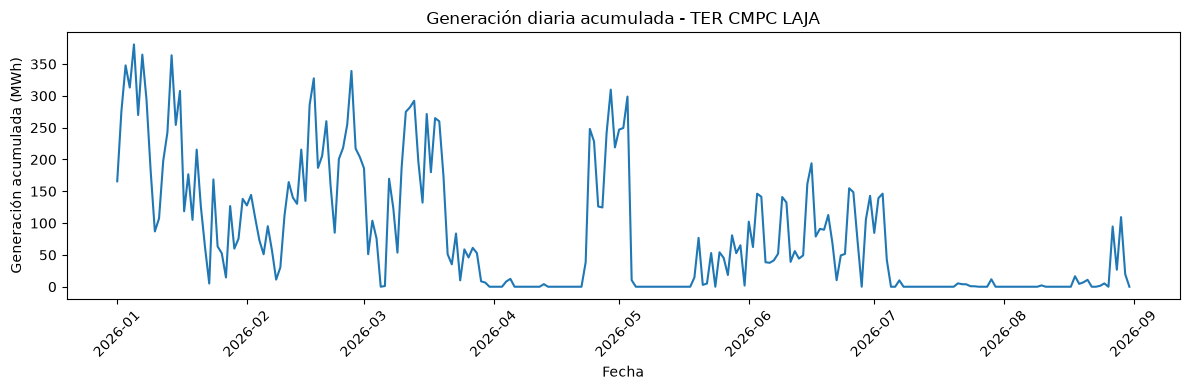

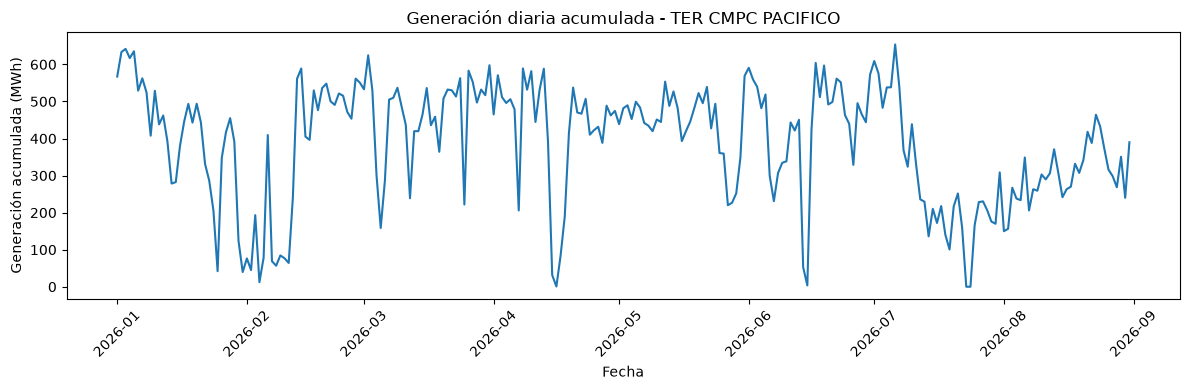

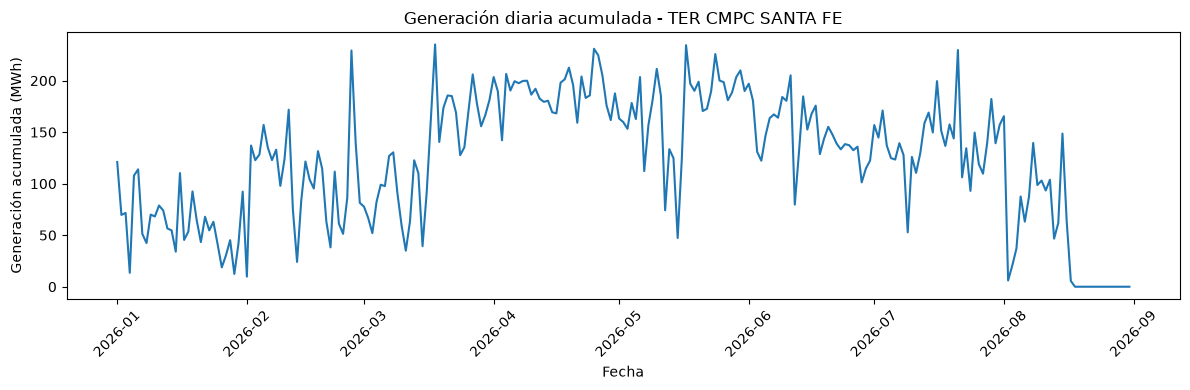

In [17]:
generacion_diaria = (
    df.groupby(["Fecha", "Central"], as_index=False)["Generacion_MWh"]
    .sum()
)

for central in centrales_objetivo:
    datos_central = generacion_diaria[
        generacion_diaria["Central"] == central
    ]

    plt.figure(figsize=(12, 4))
    plt.plot(
        datos_central["Fecha"],
        datos_central["Generacion_MWh"]
    )
    plt.title(f"Generación diaria acumulada - {central}")
    plt.xlabel("Fecha")
    plt.ylabel("Generación acumulada (MWh)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


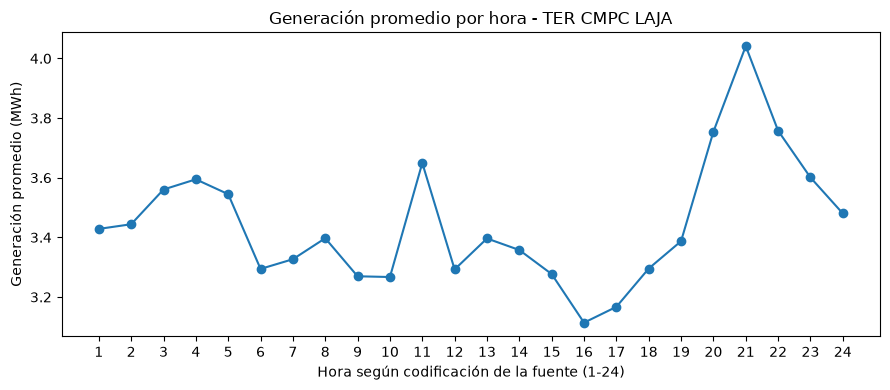

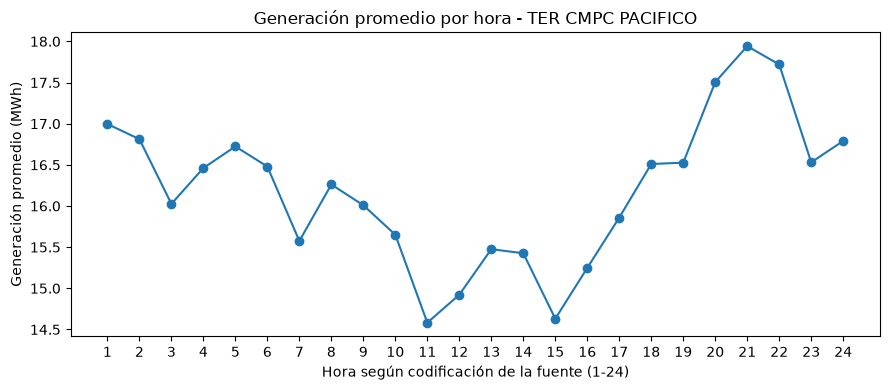

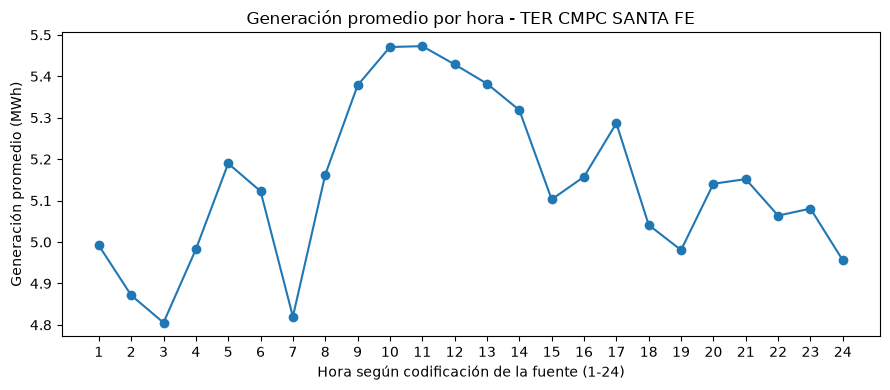

In [18]:
perfil_horario = (
    df.groupby(["Central", "Hora"], as_index=False)["Generacion_MWh"]
    .mean()
)

for central in centrales_objetivo:
    datos_central = perfil_horario[
        perfil_horario["Central"] == central
    ]

    plt.figure(figsize=(9, 4))
    plt.plot(
        datos_central["Hora"],
        datos_central["Generacion_MWh"],
        marker="o"
    )
    plt.title(f"Generación promedio por hora - {central}")
    plt.xlabel("Hora según codificación de la fuente (1-24)")
    plt.ylabel("Generación promedio (MWh)")
    plt.xticks(range(1, 25))
    plt.tight_layout()
    plt.show()


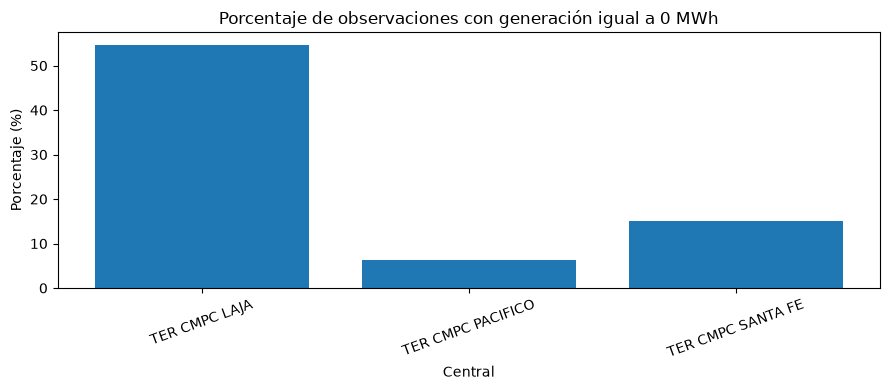

In [19]:
plt.figure(figsize=(9, 4))
plt.bar(
    ceros_por_central.index,
    ceros_por_central["Porcentaje_Ceros"]
)
plt.title("Porcentaje de observaciones con generación igual a 0 MWh")
plt.xlabel("Central")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


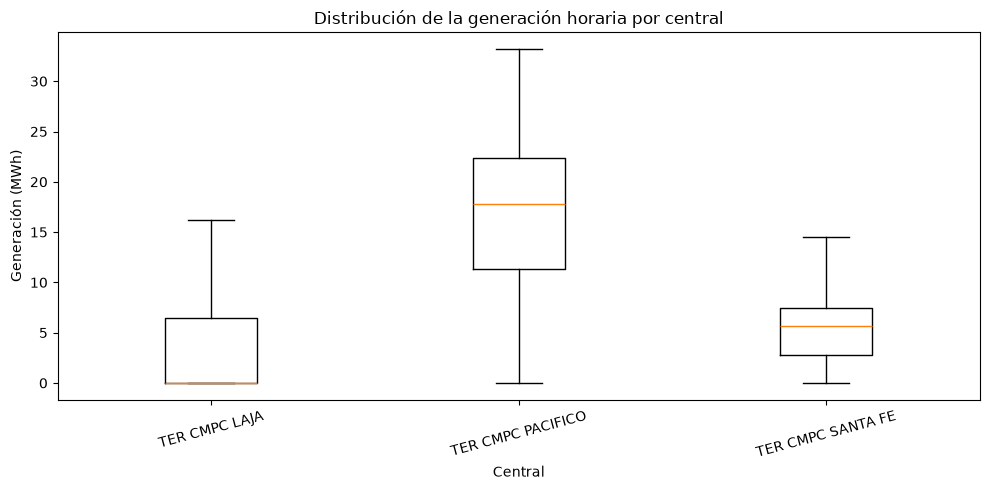

In [20]:
# Distribución de la generación por central

datos_grafico = [
    df.loc[df["Central"] == central, "Generacion_MWh"]
    for central in centrales_objetivo
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    datos_grafico,
    tick_labels=centrales_objetivo,
    showfliers=False
)

plt.title("Distribución de la generación horaria por central")
plt.xlabel("Central")
plt.ylabel("Generación (MWh)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


## 15. Función de validación reutilizable

Se encapsulan varias comprobaciones en una función para que puedan repetirse después de exportar y volver a cargar los datos.


In [21]:
def validar_dataset_procesado(datos: pd.DataFrame) -> dict:
    """Ejecuta comprobaciones mínimas del dataset analítico."""

    columnas_requeridas = set(columnas_finales)

    resultados = {
        "filas_minimas": datos.shape[0] >= 2000,
        "columnas_minimas": datos.shape[1] >= 12,
        "columnas_requeridas": columnas_requeridas.issubset(datos.columns),
        "sin_duplicados_exactos": datos.duplicated().sum() == 0,
        "id_unico": datos["ID_Observacion"].is_unique,
        "max_nulos_menor_igual_60": datos.isna().mean().max() <= 0.60,
        "tres_centrales": set(datos["Central"].unique()) == set(centrales_objetivo),
        "hora_1_a_24": datos["Hora"].between(1, 24).all(),
    }

    return resultados


resultados_validacion = validar_dataset_procesado(df)

display(
    pd.Series(resultados_validacion, name="Cumple")
    .to_frame()
)

assert all(resultados_validacion.values()),     "Una o más validaciones del dataset procesado no fueron superadas."


,Cumple
filas_minimas,True
columnas_minimas,True
columnas_requeridas,True
sin_duplicados_exactos,True
id_unico,True
max_nulos_menor_igual_60,True
tres_centrales,True
hora_1_a_24,True


## 16. Pruebas de casos límite y excepciones

Se incluyen pruebas simples para evidenciar control del flujo de ejecución.


In [22]:
# Caso límite: identificador duplicado creado artificialmente.
df_prueba = pd.concat([df.head(1), df.head(1)], ignore_index=True)

assert not df_prueba["ID_Observacion"].is_unique

print(
    "Prueba de duplicidad controlada superada: "
    "la validación detectaría un ID repetido."
)


Prueba de duplicidad controlada superada: la validación detectaría un ID repetido.


In [23]:
# Excepción controlada: demostración de validación de archivo inexistente.
ruta_inexistente = ruta_proyecto / "data" / "raw" / "archivo_que_no_existe.csv"

try:
    if not ruta_inexistente.exists():
        raise FileNotFoundError(f"Archivo no encontrado: {ruta_inexistente}")
except FileNotFoundError as error:
    print("Excepción controlada correctamente:")
    print(error)


Excepción controlada correctamente:
Archivo no encontrado: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\raw\archivo_que_no_existe.csv


## 17. Exportación del dataset procesado

El resultado analítico se guarda en `data/processed`.

A diferencia del archivo RAW, este archivo es suficientemente pequeño para ser versionado y representa el producto reproducible de la Fase 2.


In [24]:
ruta_processed.parent.mkdir(
    parents=True,
    exist_ok=True
)

df.to_csv(
    ruta_processed,
    index=False,
    encoding="utf-8-sig"
)

tamano_mb = ruta_processed.stat().st_size / (1024 ** 2)

print("Dataset exportado correctamente.")
print("Ruta:", ruta_processed)
print("Tamaño:", round(tamano_mb, 2), "MB")

assert tamano_mb < 100,     "El archivo procesado supera el límite de 100 MB."


Dataset exportado correctamente.
Ruta: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\processed\dataset_cen_centrales_cmpc_ene_ago_2026.csv
Tamaño: 2.78 MB


## 18. Verificación posterior a la exportación

El archivo recién generado se vuelve a leer para verificar que pueda recuperarse correctamente y que conserve sus dimensiones e identificadores.


In [25]:
df_verificacion = pd.read_csv(
    ruta_processed,
    encoding="utf-8-sig",
    parse_dates=["Fecha"]
)

assert df_verificacion.shape == df.shape,     "Las dimensiones cambiaron después de exportar y volver a leer."

assert df_verificacion["ID_Observacion"].is_unique,     "El identificador dejó de ser único después de la exportación."

assert set(df_verificacion.columns) == set(df.columns),     "Las columnas cambiaron después de la exportación."

print("Verificación posterior a la exportación superada.")
print("Dimensiones recuperadas:", df_verificacion.shape)


Verificación posterior a la exportación superada.
Dimensiones recuperadas: (17496, 13)


## 19. Resumen final de la Fase 2

El flujo reproducible de esta fase es:

**Descarga pública CEN**  
→ validación de estructura  
→ selección de TER CMPC LAJA, TER CMPC PACIFICO y TER CMPC SANTA FE  
→ transformación de 24 columnas horarias a formato largo  
→ creación de variables derivadas  
→ validaciones de calidad y granularidad  
→ exploración estadística y visual  
→ exportación del dataset analítico  
→ relectura y validación final.

### Resultado esperado

- **17.496 observaciones**
- **13 variables**
- **3 centrales**
- **243 fechas por central**
- **24 observaciones horarias por fecha y central**
- **0 duplicados de `ID_Observacion`**
- valores cero conservados como registros válidos
- archivo procesado menor a 100 MB

Este procedimiento permite reconstruir el dataset analítico a partir de la fuente pública original, fortaleciendo la **reproducibilidad** del proyecto.
